## Task 1: Server Cluster Reliability (Theory)

Assume we have a small server cluster with $n = 5$ independent nodes. The probability that any individual node is online and functioning correctly during a stress test is $p = 0.9$. The probability of a node failing is $(1-p) = 0.1$.

Let $X$ be the random variable representing the number of online nodes.

**Tasks:**
1. What is the probability that all 5 nodes are online?
2. What is the probability that exactly 4 nodes are online? *(Hint: Remember to account for combinations, as any one of the 5 nodes could be the single failure).*
3. Write the generalized Probability Mass Function $P(X=x)$ for an arbitrary number of online nodes $x$.

---

**1. Probability of 5 nodes online:**
Since the nodes are independent, we multiply the probability of success for each:
$$P(X=5) = 0.9 \cdot 0.9 \cdot 0.9 \cdot 0.9 \cdot 0.9 = (0.9)^5 \approx 0.5905$$

**2. Probability of exactly 4 nodes online:**
First, calculate the probability of a specific sequence (e.g., 4 online, 1 offline): $(0.9)^4 \cdot (0.1)^1$. 
However, since we don't care *which* node fails, we must multiply by the number of possible combinations (5 choose 4):
$$P(X=4) = \binom{5}{4} \cdot (0.9)^4 \cdot (0.1)^1 = 5 \cdot 0.6561 \cdot 0.1 \approx 0.3281$$

**3. The Generalized PMF (Binomial Distribution):**
Following the pattern above, for $n=5$ total nodes and $x$ online nodes:
$$P(X=x) = \binom{5}{x} \cdot p^x \cdot (1-p)^{5-x}$$
</details>

---
## Task 2: API Connection Retries (Programming)

In our lecture, we discussed the Geometric Distribution using the example of a student taking an exam multiple times until they pass. Let's apply this to a data engineering scenario.

A script is trying to pull data from an unstable external API. Each time it makes a request, the probability of a successful connection is $p = 0.2$. If it fails, the script retries. 

Let $X$ be the random variable representing the **total number of attempts** required to get the first success.

**Your Goal:**
1. Simulate $100,000$ independent scripts trying to connect to the API. Record how many attempts each script takes.
2. Plot the empirical relative frequencies of your simulation as a bar chart.
3. Overlay the theoretical Geometric Distribution PMF curve on top of your bars to prove your simulation works!

*Theoretical Formula:* $P(X=r) = (1-p)^{r-1} \cdot p$

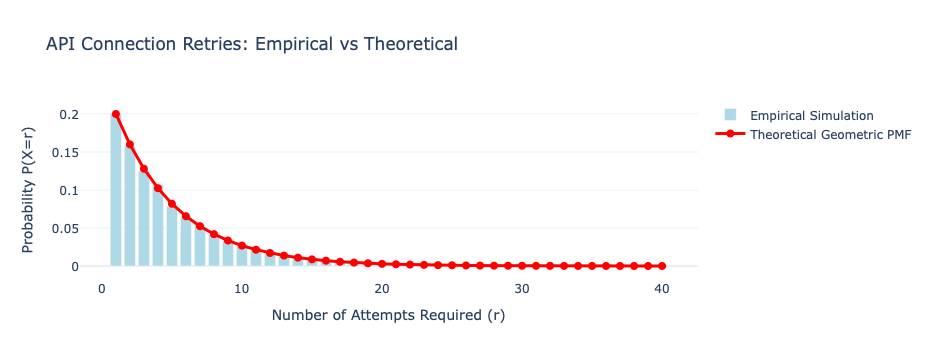

In [2]:
import numpy as np
import plotly.graph_objects as go
import scipy.stats as stats

p_success = 0.2
n_simulations = 10000

# 1. EMPIRICAL SIMULATION
# np.random.geometric simulates the exact scenario: number of trials until first success
empirical_attempts = np.random.geometric(p=p_success, size=n_simulations)

# Count the frequencies of each outcome (1 attempt, 2 attempts, 3 attempts...)
unique_vals, counts = np.unique(empirical_attempts, return_counts=True)
empirical_probs = counts / n_simulations

# 2. THEORETICAL PMF
# Calculate the exact mathematical probabilities for the same range of attempts
x_theoretical = np.arange(1, max(unique_vals) + 1)
y_theoretical = (1 - p_success) ** (x_theoretical - 1) * p_success

# 3. PLOTLY VISUALIZATION
fig = go.Figure()

# Add empirical bar chart
fig.add_trace(
    go.Bar(
        x=unique_vals,
        y=empirical_probs,
        name="Empirical Simulation",
        marker_color="lightblue",
    )
)

# Add theoretical line
fig.add_trace(
    go.Scatter(
        x=x_theoretical,
        y=y_theoretical,
        mode="lines+markers",
        name="Theoretical Geometric PMF",
        line=dict(color="red", width=3),
        marker=dict(size=8, color="red"),
    )
)

fig.update_layout(
    title="API Connection Retries: Empirical vs Theoretical",
    xaxis_title="Number of Attempts Required (r)",
    yaxis_title="Probability P(X=r)",
    template="plotly_white",
)

fig.show()

---
## 💡 Optional Visual Aid: The Binomial Probability Mass Function

*Note: This section is purely an interactive visualization to help you build intuition!*

In the lecture, we looked at a club with 16 members, asking how many will be present at a meeting. Intuitively, if the probability of each person attending is $p=0.5$, we expect the peak to be around 8 people.

Run the cell below to load an interactive Plotly chart. Drag the slider to change $p$ (the probability of an individual attending) and watch how the entire Probability Mass Function shifts in response!

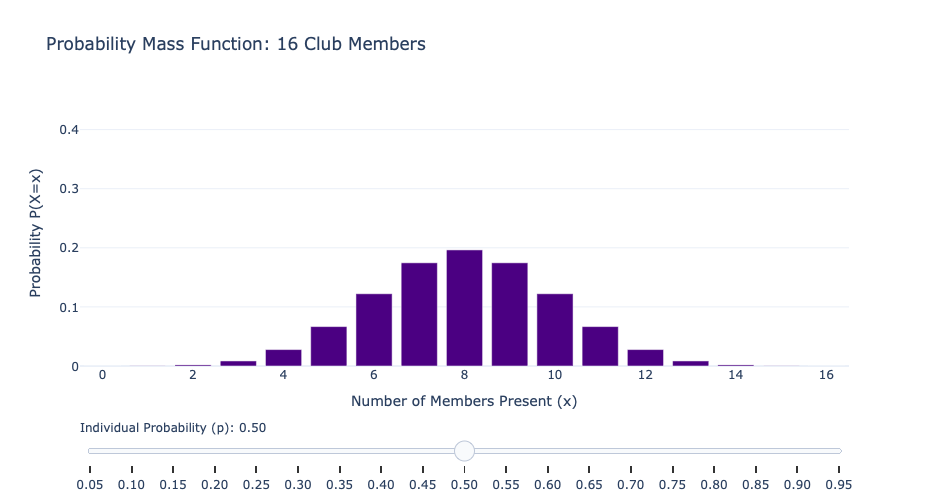

In [6]:
import numpy as np
import plotly.graph_objects as go
from scipy.special import comb

n_members = 2**4
x_vals = np.arange(0, n_members + 1)


# Function to calculate Binomial PMF: 16Cr * p^r * (1-p)^(16-r)
def calc_pmf(p):
    return comb(n_members, x_vals) * (p**x_vals) * ((1 - p) ** (n_members - x_vals))


# Initialize figure with p = 0.5
fig = go.Figure()
fig.add_trace(go.Bar(x=x_vals, y=calc_pmf(0.5), marker_color="indigo"))

# Create slider steps for p ranging from 0.05 to 0.95
steps = []
probabilities = np.arange(0.05, 1.0, 0.05)

for p in probabilities:
    step = dict(method="update", args=[{"y": [calc_pmf(p)]}], label=f"{p:.2f}")
    steps.append(step)

sliders = [
    dict(
        active=9,  # Index for p=0.5
        currentvalue={"prefix": "Individual Probability (p): "},
        pad={"t": 50},
        steps=steps,
    )
]

fig.update_layout(
    title="Probability Mass Function: 16 Club Members",
    xaxis_title="Number of Members Present (x)",
    yaxis_title="Probability P(X=x)",
    yaxis=dict(range=[0, 0.45]),  # Lock Y axis so it doesn't jump around
    sliders=sliders,
    template="plotly_white",
    height=500,
)

fig.show()